In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import het_breuschpagan, het_white

from linearmodels.panel import (
    PooledOLS, RandomEffects, PanelOLS, FirstDifferenceOLS, compare,
)

sns.set_style("whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

In [ ]:
RUTA = "guns_panel_extendido_1979_2022.csv"
guns = pd.read_csv(RUTA)
guns = guns.rename(columns={"state_abbr": "state"})
filas_incompletas = guns[guns[["population", "violent", "murder", "robbery"]].isnull().any(axis=1)]
if len(filas_incompletas):
    print(f"Se descartan {len(filas_incompletas)} fila(s) con datos faltantes:")
    print(filas_incompletas[["state", "year"]])
    guns = guns.dropna(subset=["population", "violent", "murder", "robbery"]).copy()

Se descartan 1 fila(s) con datos faltantes:
     state  year
1275    ND  2022


In [ ]:
def pvar_summary(df, entity_col, time_col):
    novar_time, novar_ind = [], []
    for col in df.columns:
        if col in (entity_col, time_col):
            continue
        try:
            var_in_entity = df.groupby(entity_col)[col].nunique(dropna=False).max()
            var_in_time = df.groupby(time_col)[col].nunique(dropna=False).max()
        except TypeError:
            continue
        if var_in_entity <= 1:
            novar_time.append(col)
        if var_in_time <= 1:
            novar_ind.append(col)
    return novar_time, novar_ind

def pdim_summary(df, entity_col, time_col):
    n = df[entity_col].nunique()
    t_counts = df.groupby(entity_col)[time_col].nunique()
    balanceado = t_counts.nunique() == 1
    T = t_counts.iloc[0] if balanceado else t_counts.mean()
    N = len(df)
    return {"n_individuos": n, "T_periodos": T, "N_obs": N, "balanceado": balanceado}

def hausman_test(fe_result, re_result):
    b_fe, b_re = fe_result.params, re_result.params
    common = b_fe.index.intersection(b_re.index).drop("const", errors="ignore")
    b_diff = (b_fe[common] - b_re[common]).values
    v_diff = (fe_result.cov.loc[common, common] - re_result.cov.loc[common, common]).values
    stat = float(b_diff.T @ np.linalg.inv(v_diff) @ b_diff)
    df = len(common)
    pval = 1 - stats.chi2.cdf(stat, df)
    return stat, df, pval

def plm_lm_test(pooled_result, effect="individual"):
    e = pooled_result.resids
    idx_names = e.index.names

    def _lm_one_way(resid, group_level, other_size):
        g = resid.groupby(level=group_level)
        n_groups = g.ngroups
        Tbar = other_size
        sum_e2 = (resid ** 2).sum()
        sum_group_sq = (g.sum() ** 2).sum()
        lm = (n_groups * Tbar / (2 * (Tbar - 1))) * ((sum_group_sq / sum_e2) - 1) ** 2
        return lm

    N = e.index.get_level_values(idx_names[0]).nunique()
    T = e.index.get_level_values(idx_names[1]).nunique()

    if effect == "individual":
        lm = _lm_one_way(e, idx_names[0], T); df = 1
    elif effect == "time":
        lm = _lm_one_way(e, idx_names[1], N); df = 1
    elif effect == "twoways":
        lm = _lm_one_way(e, idx_names[0], T) + _lm_one_way(e, idx_names[1], N); df = 2
    else:
        raise ValueError("effect debe ser 'individual', 'time' o 'twoways'")
    pval = 1 - stats.chi2.cdf(lm, df)
    return lm, df, pval

def wooldridge_serial_test(fd_result, h0="fe"):
    """H0: no hay autocorrelacion serial en los errores idiosincraticos del
    modelo de niveles. Se aplica sobre los residuos de Primeras Diferencias:
    si el modelo de EF es correcto, Corr(e_it_FD, e_i,t-1_FD) = -0.5.
    """
    e = fd_result.resids
    d = e.reset_index()
    d.columns = ["entity", "time", "e"]
    d = d.sort_values(["entity", "time"])
    d["e_lag"] = d.groupby("entity")["e"].shift(1)
    d = d.dropna()
    import statsmodels.formula.api as smf
    mod = smf.ols("e ~ e_lag - 1", data=d).fit(
        cov_type="cluster", cov_kwds={"groups": d["entity"]}
    )
    coef = mod.params["e_lag"]; se = mod.bse["e_lag"]
    target = -0.5 if h0 == "fe" else 0.0
    t_stat = (coef - target) / se
    df_resid = mod.df_resid
    pval = 2 * (1 - stats.t.cdf(abs(t_stat), df_resid))
    return coef, se, t_stat, pval

def pesaran_cd_test(resid_series):
    """H0: no hay dependencia transversal (los residuos de distintos estados
    no estan correlacionados entre si en un mismo periodo)."""
    d = resid_series.reset_index()
    d.columns = ["entity", "time", "e"]
    wide = d.pivot(index="time", columns="entity", values="e")
    corr = wide.corr()
    N = corr.shape[0]; T = wide.shape[0]
    iu = np.triu_indices(N, k=1)
    rho_sum = corr.values[iu].sum()
    cd_stat = np.sqrt(2 * T / (N * (N - 1))) * rho_sum
    pval = 2 * (1 - stats.norm.cdf(abs(cd_stat)))
    return cd_stat, pval

# ---- Funciones NUEVAS de diagnostico (no estaban en Guns.py) --------------
def jarque_bera_normalidad(resid):
    """H0: los residuos se distribuyen normal (asimetria=0, curtosis=3)."""
    jb_stat, jb_p, skew, kurt = jarque_bera(np.asarray(resid))
    return jb_stat, jb_p, skew, kurt

def bp_white_heterocedasticidad(resid, X):
    """Breusch-Pagan y White. H0: varianza del error constante (homocedasticidad).
    Se corre sobre los residuos del modelo de EF, usando como regresores las
    variables explicativas 'within' (X ya centrada implicitamente por PanelOLS)."""
    X_const = sm.add_constant(X)
    bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(resid, X_const)
    w_lm, w_lm_p, w_f, w_f_p = het_white(resid, X_const)
    return {
        "BP_LM": bp_lm, "BP_LM_p": bp_lm_p,
        "White_LM": w_lm, "White_LM_p": w_lm_p,
    }

def wald_modificado_heterocedasticidad_grupal(fe_result, entity_name="state"):
    """Test de Wald modificado (Greene 2000 / analogo a 'xttest3' de Stata).
    H0: la varianza del error es igual entre todos los estados (homocedasticidad
    'entre grupos'). Util cuando se sospecha que unos estados son mas
    'ruidosos' que otros (p. ej. estados pequenos con conteos de crimen bajos)."""
    e = fe_result.resids.reset_index()
    e.columns = [entity_name, "time", "e"]
    sigma2_i = e.groupby(entity_name)["e"].apply(lambda x: (x ** 2).mean())
    Ti = e.groupby(entity_name)["e"].count()
    sigma2 = (e["e"] ** 2).mean()
    stat = float(((sigma2_i - sigma2) ** 2 / (2 * sigma2 ** 2 / Ti)).sum())
    df = len(sigma2_i)
    pval = 1 - stats.chi2.cdf(stat, df)
    return stat, df, pval

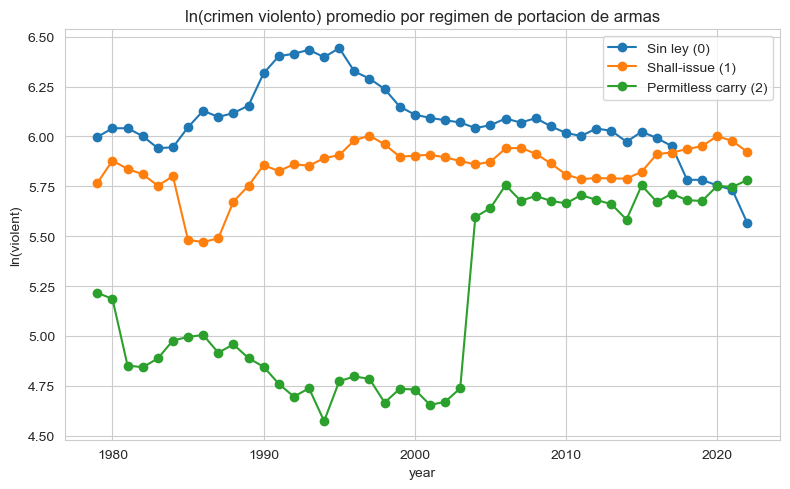

In [ ]:
mean_by_group = guns.groupby(["year", "shall_level"])["ln_violent"].mean().unstack()
mean_by_group.columns = ["Sin ley (0)", "Shall-issue (1)", "Permitless carry (2)"]
mean_by_group.plot(figsize=(8, 5), marker="o")
plt.title("ln(crimen violento) promedio por regimen de portacion de armas")
plt.ylabel("ln(violent)")
plt.tight_layout()
plt.savefig("grafico_ln_violent_por_regimen.png", dpi=150)
plt.show()

In [ ]:
y = panel_guns["ln_violent"]
X = panel_guns[["shall_issue", "permitless", "ln_income", "ln_population"]].astype(float)

year_dummies = pd.get_dummies(panel_guns["year"], prefix="yr", drop_first=True).astype(float)
X_full = pd.concat([X, year_dummies], axis=1)
X_const = sm.add_constant(X_full)
X_plain_const = sm.add_constant(X)

pooled = PooledOLS(y, X_const).fit()
random = RandomEffects(y, X_const).fit()
FD     = FirstDifferenceOLS(y, X_full).fit()
fixed  = PanelOLS(y, X_plain_const, entity_effects=True, time_effects=True).fit()

tabla_comparativa = compare({"Pooled": pooled, "EA": random, "EF": fixed, "PD": FD}, stars=True)
print(tabla_comparativa)

                                       Model Comparison                                       
                                Pooled                EA             EF                     PD
----------------------------------------------------------------------------------------------
Dep. Variable               ln_violent        ln_violent     ln_violent             ln_violent
Estimator                    PooledOLS     RandomEffects       PanelOLS     FirstDifferenceOLS
No. Observations                  2243              2243           2243                   2192
Cov. Est.                   Unadjusted        Unadjusted     Unadjusted             Unadjusted
R-squared                       0.2287            0.2843         0.1131                 0.1975
R-Squared (Within)              0.1260            0.2856        -7.0200                 0.2270
R-Squared (Between)             0.2542           -0.5306        -0.5915                -1.7521
R-Squared (Overall)             0.2287           -

In [ ]:
# 5.1 LM de Breusch-Pagan/Honda: Pooled vs EA.
#     H0: var(efecto individual) = 0  ->  si se rechaza, Pooled es inadecuado.
lm_ind, df_ind, p_ind = plm_lm_test(pooled, effect="individual")
print(f"LM Breusch-Pagan/Honda (Pooled vs EA): chi2({df_ind}) = {lm_ind:.3f}, p = {p_ind:.4g}")

# 5.2 Test de Hausman: EA vs EF.
#     H0: EA es consistente y eficiente (no hay correlacion entre efectos
#     individuales no observados y los regresores). Si se rechaza -> usar EF.
hausman_stat, hausman_df, hausman_p = hausman_test(fixed, random)
print(f"Hausman: chi2({hausman_df}) = {hausman_stat:.3f}, p = {hausman_p:.4g}")

LM Breusch-Pagan/Honda (Pooled vs EA): chi2(1) = 28792.704, p = 0
Hausman: chi2(4) = 2.314, p = 0.6783


In [ ]:
# Se asume, sujeto a lo que arroje el Hausman, que EF es el modelo de partida
# por argumento economico (cultura politica/institucional no observada del
# estado esta correlacionada con adoptar leyes de portacion mas laxas).

resid_fe = fixed.resids

print("\n=== 6.1 NORMALIDAD: Jarque-Bera ===")
jb_stat, jb_p, skew, kurt = jarque_bera_normalidad(resid_fe)
print(f"JB = {jb_stat:.3f}, p = {jb_p:.4g}, asimetria = {skew:.3f}, curtosis = {kurt:.3f}")
# H0: los residuos son normales. Con N grande (miles de obs) el Teorema Central
# del Limite garantiza que los estimadores siguen siendo asintoticamente
# normales aunque se rechace H0; no invalida el modelo, solo indica que los
# p-values "exactos" en muestras pequenas no aplicarian 

print("\n=== 6.2 HETEROCEDASTICIDAD ===")
het_res = bp_white_heterocedasticidad(resid_fe, X)
print(f"Breusch-Pagan: LM = {het_res['BP_LM']:.3f}, p = {het_res['BP_LM_p']:.4g}")
print(f"White:         LM = {het_res['White_LM']:.3f}, p = {het_res['White_LM_p']:.4g}")

wald_stat, wald_df, wald_p = wald_modificado_heterocedasticidad_grupal(fixed, "state")
print(f"Wald modificado (heterocedasticidad ENTRE estados): "
      f"chi2({wald_df}) = {wald_stat:.3f}, p = {wald_p:.4g}")
# H0 (los tres tests): homocedasticidad. 
print("\n=== 6.3 AUTOCORRELACION SERIAL: Wooldridge ===")
coef_fe, se_fe, t_fe, p_fe = wooldridge_serial_test(FD, h0="fe")
print(f"coef(e_lag) = {coef_fe:.4f} (H0: -0.5), t = {t_fe:.3f}, p = {p_fe:.4g}")
# H0: no hay autocorrelacion serial adicional a la ya implicita en el modelo
# de EF. Con datos anuales de crimen es esperable rechazar H0: el crimen de
# un estado en el año t esta muy correlacionado con el crimen en t-1
# (inercia social/policial).

print("\n=== 6.4 DEPENDENCIA TRANSVERSAL: Pesaran CD ===")
cd_stat, cd_p = pesaran_cd_test(resid_fe)
print(f"CD = {cd_stat:.3f}, p = {cd_p:.4g}")
# H0: no hay dependencia transversal. Es plausible rechazarla


=== 6.1 NORMALIDAD: Jarque-Bera ===
JB = 249.837, p = 5.604e-55, asimetria = 0.179, curtosis = 4.595

=== 6.2 HETEROCEDASTICIDAD ===
Breusch-Pagan: LM = 140.876, p = 1.833e-29
White:         LM = 490.625, p = 3.199e-98
Wald modificado (heterocedasticidad ENTRE estados): chi2(51) = 1771.367, p = 0

=== 6.3 AUTOCORRELACION SERIAL: Wooldridge ===
coef(e_lag) = 0.0196 (H0: -0.5), t = 20.455, p = 0

=== 6.4 DEPENDENCIA TRANSVERSAL: Pesaran CD ===
CD = -1.206, p = 0.2278


In [ ]:
# Regla de decision:
#  - Heterocedasticidad y/o autocorrelacion -> usar SE robustos clustered por estado

print("\n=== 7.1 CORRECCION: SE clustered por estado ===")
fixed_clustered = PanelOLS(y, X_plain_const, entity_effects=True, time_effects=True).fit(
    cov_type="clustered", cluster_entity=True
)
print(fixed_clustered)

print("\n=== 7.2 CORRECCION: SE de Driscoll-Kraay (robustos a CSD, hetero y autocorr) ===")
fixed_dk = PanelOLS(y, X_plain_const, entity_effects=True, time_effects=True).fit(
    cov_type="kernel", kernel="bartlett"
)
print(fixed_dk)


=== 7.1 CORRECCION: SE clustered por estado ===
                          PanelOLS Estimation Summary                           
Dep. Variable:             ln_violent   R-squared:                        0.1131
Estimator:                   PanelOLS   R-squared (Between):             -0.5915
No. Observations:                2243   R-squared (Within):              -7.0200
Date:                Thu, Jul 30 2026   R-squared (Overall):             -1.8456
Time:                        08:27:03   Log-likelihood                    295.46
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      68.391
Entities:                          51   P-value                           0.0000
Avg Obs:                       43.980   Distribution:                  F(4,2145)
Min Obs:                       43.000                                           
Max Obs:                       44.000   F-statistic (robust)

In [ ]:
tabla_se = compare(
    {"EF (SE clasicos)": fixed, "EF (clustered estado)": fixed_clustered,
     "EF (Driscoll-Kraay)": fixed_dk},
    stars=True,
)
print(tabla_se)
# Los coeficientes NO cambian entre las tres columnas (misma estimacion
# puntual); lo que cambia es la precision (errores estandar) y por tanto la
# significancia estadistica. Esta es la version que se reporta como
# resultado final del podcast.

                                 Model Comparison                                 
                        EF (SE clasicos) EF (clustered estado) EF (Driscoll-Kraay)
----------------------------------------------------------------------------------
Dep. Variable                 ln_violent            ln_violent          ln_violent
Estimator                       PanelOLS              PanelOLS            PanelOLS
No. Observations                    2243                  2243                2243
Cov. Est.                     Unadjusted             Clustered      Driscoll-Kraay
R-squared                         0.1131                0.1131              0.1131
R-Squared (Within)               -7.0200               -7.0200             -7.0200
R-Squared (Between)              -0.5915               -0.5915             -0.5915
R-Squared (Overall)              -1.8456               -1.8456             -1.8456
F-statistic                       68.391                68.391              68.391
P-va

In [ ]:
print("\n=== Robustez: murder y robbery, con Driscoll-Kraay ===")
for var_dep in ["ln_murder", "ln_robbery"]:
    y_alt = panel_guns[var_dep]
    fe_alt = PanelOLS(y_alt, X_plain_const, entity_effects=True, time_effects=True).fit(
        cov_type="kernel", kernel="bartlett"
    )
    print(f"\n--- Variable dependiente: {var_dep} ---")
    print(fe_alt.params[["shall_issue", "permitless"]])
    print(fe_alt.pvalues[["shall_issue", "permitless"]])


=== Robustez: murder y robbery, con Driscoll-Kraay ===

--- Variable dependiente: ln_murder ---
shall_issue    0.018080
permitless     0.048986
Name: parameter, dtype: float64
shall_issue    0.425727
permitless     0.233217
Name: pvalue, dtype: float64

--- Variable dependiente: ln_robbery ---
shall_issue    0.058792
permitless     0.217921
Name: parameter, dtype: float64
shall_issue    0.048288
permitless     0.002286
Name: pvalue, dtype: float64


In [ ]:
# Efectos Aleatorios FINAL con SE clustered por estado
# (el modelo elegido por Hausman, con la correccion que ya sabemos que hace falta)
random_clustered = RandomEffects(y, X_const).fit(
    cov_type="clustered", cluster_entity=True
)
print(random_clustered)

                        RandomEffects Estimation Summary                        
Dep. Variable:             ln_violent   R-squared:                        0.2843
Estimator:              RandomEffects   R-squared (Between):             -0.5306
No. Observations:                2243   R-squared (Within):               0.2856
Date:                Thu, Jul 30 2026   R-squared (Overall):             -0.3713
Time:                        08:27:12   Log-likelihood                    291.73
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      18.554
Entities:                          51   P-value                           0.0000
Avg Obs:                       43.980   Distribution:                 F(47,2195)
Min Obs:                       43.000                                           
Max Obs:                       44.000   F-statistic (robust):             145.72
                            

In [ ]:
# Tabla final: el modelo que vas a reportar en el podcast
tabla_final = compare(
    {"EA (SE clasicos)": random,
     "EA (clustered estado) -- MODELO FINAL": random_clustered,
     "EF (clustered estado) -- robustez": fixed_clustered},
    stars=True,
)
print(tabla_final)

                                                 Model Comparison                                                
                         EA (SE clasicos) EA (clustered estado) -- MODELO FINAL EF (clustered estado) -- robustez
-----------------------------------------------------------------------------------------------------------------
Dep. Variable                  ln_violent                            ln_violent                        ln_violent
Estimator                   RandomEffects                         RandomEffects                          PanelOLS
No. Observations                     2243                                  2243                              2243
Cov. Est.                      Unadjusted                             Clustered                         Clustered
R-squared                          0.2843                                0.2843                            0.1131
R-Squared (Within)                 0.2856                                0.2856         